In [1]:
from notebooks.consts import NOTEBOOK_PATH

SEEN_MODELS_FOLDER = NOTEBOOK_PATH / 'models' / 'SeenOligoModel'

In [3]:
import xgboost as xgb
import json

# 1. Reload your trained models
model_train_val = xgb.Booster()
model_train_val.load_model(str( SEEN_MODELS_FOLDER / "Model_Oligo_L2_TrainVal.json"))

model_all = xgb.Booster()
model_all.load_model(str(SEEN_MODELS_FOLDER / "Model_Oligo_L2_AllData.json"))

# 2. Recover the optimal features directly from the model!
best_feats = model_train_val.feature_names
print(f"Successfully recovered {len(best_feats)} optimal features!")

# 3. (Optional) Load your metrics back into a dictionary
with open(str(  SEEN_MODELS_FOLDER / "Model_Oligo_L2_TrainVal_metrics.json"), "r") as f:
    train_val_metrics = json.load(f)

# Recreate the dictionary the pipeline was supposed to return
models = {'model_train_val': model_train_val, 'model_all': model_all}

Successfully recovered 41 optimal features!


In [36]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Assuming you have your data loaded: train_df, val_df, test_df, INHIBITION

def get_large_cohort_indices(df, group_cols, min_size=20):
    indices = []
    df_reset = df.reset_index(drop=True)
    for cohort, group in df_reset.groupby(group_cols):
        if len(group) >= min_size:
            indices.append(group.index.values)
    return indices

def evaluate_predictions(preds, y_true, eval_groups):
    """Calculates Spearman, MAE, RMSD, and Top K% Medians."""
    mae = mean_absolute_error(y_true, preds)
    rmsd = np.sqrt(mean_squared_error(y_true, preds))

    spearmans, top_1_medians, top_5_medians = [], [], []
    for idxs in eval_groups:
        t_vals, p_vals = y_true[idxs], preds[idxs]

        corr, _ = spearmanr(t_vals, p_vals)
        if not np.isnan(corr): spearmans.append(corr)

        n = len(t_vals)
        k1, k5 = max(1, int(n * 0.01)), max(1, int(n * 0.05))

        if k5 > 0: top_5_medians.append(np.median(t_vals[np.argpartition(p_vals, -k5)[-k5:]]))
        if k1 > 0: top_1_medians.append(np.median(t_vals[np.argpartition(p_vals, -k1)[-k1:]]))

    return {
        "MAE": float(mae),
        "RMSD": float(rmsd),
        "Spearman": float(np.nanmedian(spearmans)) if spearmans else 0.0,
        "Top1_Inhib": float(np.nanmedian(top_1_medians)) if top_1_medians else 0.0,
        "Top5_Inhib": float(np.nanmedian(top_5_medians)) if top_5_medians else 0.0
    }

def evaluate_multiple_models(model_configs, train_df, val_df, test_df, target_col, eval_groups_dict):
    """
    Loads models, generates predictions once, and scores them across MULTIPLE grouping strategies.
    """
    y_train, y_val, y_test = train_df[target_col].values, val_df[target_col].values, test_df[target_col].values
    all_metrics = []

    print(f"Evaluating {len(model_configs)} configurations across {len(eval_groups_dict)} grouping strategies...")
    for model_name, config in model_configs.items():
        try:
            # 1. Handle Baseline
            if config.get('is_baseline', False):
                baseline_col = config['baseline_col']
                preds_train = train_df[baseline_col].values
                preds_val = val_df[baseline_col].values
                preds_test = test_df[baseline_col].values
                print(f"✅ Loaded Baseline: '{model_name}'")
            # 2. Handle XGBoost Models
            else:
                bst = xgb.Booster()
                bst.load_model(config['path'])
                model_features = bst.feature_names

                dtrain = xgb.DMatrix(train_df[model_features].values, feature_names=model_features)
                dval = xgb.DMatrix(val_df[model_features].values, feature_names=model_features)
                dtest = xgb.DMatrix(test_df[model_features].values, feature_names=model_features)

                preds_train = bst.predict(dtrain)
                preds_val = bst.predict(dval)
                preds_test = bst.predict(dtest)
                print(f"✅ Loaded XGBoost: '{model_name}'")

            test_split_name = "Test (Leaked)" if config.get('is_all_data', False) else "Test"

            # 3. Score across all Grouping Strategies dynamically
            for group_label, group_cols in eval_groups_dict.items():
                train_eval_idx = get_large_cohort_indices(train_df, group_cols)
                val_eval_idx = get_large_cohort_indices(val_df, group_cols)
                test_eval_idx = get_large_cohort_indices(test_df, group_cols)

                metrics_train = evaluate_predictions(preds_train, y_train, train_eval_idx)
                metrics_val = evaluate_predictions(preds_val, y_val, val_eval_idx)
                metrics_test = evaluate_predictions(preds_test, y_test, test_eval_idx)

                for split, metrics in [("Train", metrics_train), ("Validation", metrics_val), (test_split_name, metrics_test)]:
                    metrics["Model"] = model_name
                    metrics["Split"] = split
                    metrics["Grouping"] = group_label  # <-- Track which group generated this score
                    all_metrics.append(metrics)

        except Exception as e:
            print(f"❌ Failed to evaluate '{model_name}': {e}")

    df_results = pd.DataFrame(all_metrics)
    cols = ['Model', 'Split', 'Grouping', 'Spearman', 'Top1_Inhib', 'Top5_Inhib', 'MAE', 'RMSD']
    return df_results[cols]

In [52]:
from notebooks.models.SeenOligoModel.base_model import split_data
from notebooks.models.utility import load_and_validate_final_data

final_data, features = load_and_validate_final_data(version='oligo', load_competition=True)

# Default config
split_config = {
    'col': 'split',
    'train': 'train',
    'val': 'val',
    'test': 'test'
}

train_df, val_df, test_df = split_data(
    final_data,
    features,
    split_col=split_config["col"],
    train_val=split_config["train"],
    val_val=split_config["val"],
    test_val=split_config["test"],
)

Evaluating 14 configurations across 2 grouping strategies...
✅ Loaded Baseline: 'Competition (PFRED_PLS)'
✅ Loaded Baseline: 'Competition (PFRED_SVM)'
✅ Loaded Baseline: 'Competition (OW_Overall)'
✅ Loaded Baseline: 'Competition (OW_Tm)'
✅ Loaded Baseline: 'Competition (OW_Intra_Oligo)'
✅ Loaded Baseline: 'Competition (OW_Duplex)'
✅ Loaded Baseline: 'Competition (sfold_accessibility)'
✅ Loaded Baseline: 'Competition (miranda_score)'


/tmp/ipykernel_1590453/1728011474.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(t_vals, p_vals)
/tmp/ipykernel_1590453/1728011474.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(t_vals, p_vals)
/tmp/ipykernel_1590453/1728011474.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(t_vals, p_vals)
/tmp/ipykernel_1590453/1728011474.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(t_vals, p_vals)
/tmp/ipykernel_1590453/1728011474.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(t_vals, p_vals)
/tmp/ipykernel_1590453/1728011474.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.


✅ Loaded Baseline: 'Competition (miranda_energy)'
✅ Loaded Baseline: 'Competition (oligo_ai_score)'
✅ Loaded XGBoost: 'L2 (Train+Val)'
✅ Loaded XGBoost: 'L2 (Train+Val) [CustomId]'
✅ Loaded XGBoost: 'L1 (Train+Val)'
✅ Loaded XGBoost: 'L1 (Train+Val) [CustomId]'

--- Summary Table ---


Spearman  \
Grouping                                     Cohort (Gene x Cell Line)   
Model                             Split                                  
Competition (OW_Duplex)           Test                          0.0052   
                                  Train                        -0.0798   
                                  Validation                   -0.1069   
Competition (OW_Intra_Oligo)      Test                          0.1794   
                                  Train                        -0.0022   
                                  Validation                   -0.0373   
Competition (OW_Overall)          Test                         -0.0513   
                                  Train                        -0.0873   
                                  Validation                   -0.0921   
Competition (OW_Tm)               Test                         -0.0102   
                                  Train                         0.0721   
                                  Validation                    0.1151   
Competition (PFRED_PLS)           Test                          0.0982   
                                  Train                         0.0332   
                                  Validation                    0.0743   
Competition (PFRED_SVM)           Test                          0.1216   
                                  Train                         0.0718   
                                  Validation                    0.1267   
Competition (miranda_energy)      Test                         -0.0001   
                                  Train                        -0.0741   
                                  Validation                   -0.0915   
Competition (miranda_score)       Test                         -0.0882   
                                  Train                        -0.1069   
                                  Validation                   -0.2309   
Competition (oligo_ai_score)      Test                          0.3854   
                                  Train                         0.3213   
                                  Validation                    0.3317   
Competition (sfold_accessibility) Test                          0.0918   
                                  Train                         0.0152   
                                  Validation                    0.0923   
L1 (Train+Val)                    Test                          0.3683   
                                  Train                         0.4488   
                                  Validation                    0.4719   
L1 (Train+Val) [CustomId]         Test                          0.3766   
                                  Train                         0.4556   
                                  Validation                    0.5172   
L2 (Train+Val)                    Test                          0.4116   
                                  Train                         0.4702   
                                  Validation                    0.5337   
L2 (Train+Val) [CustomId]         Test                          0.3768   
                                  Train                         0.4561   
                                  Validation                    0.5072   

                                                                     \
Grouping                                     Experiment (custom_id)   
Model                             Split                               
Competition (OW_Duplex)           Test                       0.1476   
                                  Train                      0.0332   
                                  Validation                -0.1031   
Competition (OW_Intra_Oligo)      Test                       0.1727   
                                  Train                      0.0522   
                                  Validation                -0.0050   
Competition (OW_Overall)          Test                       0.0903   
                     

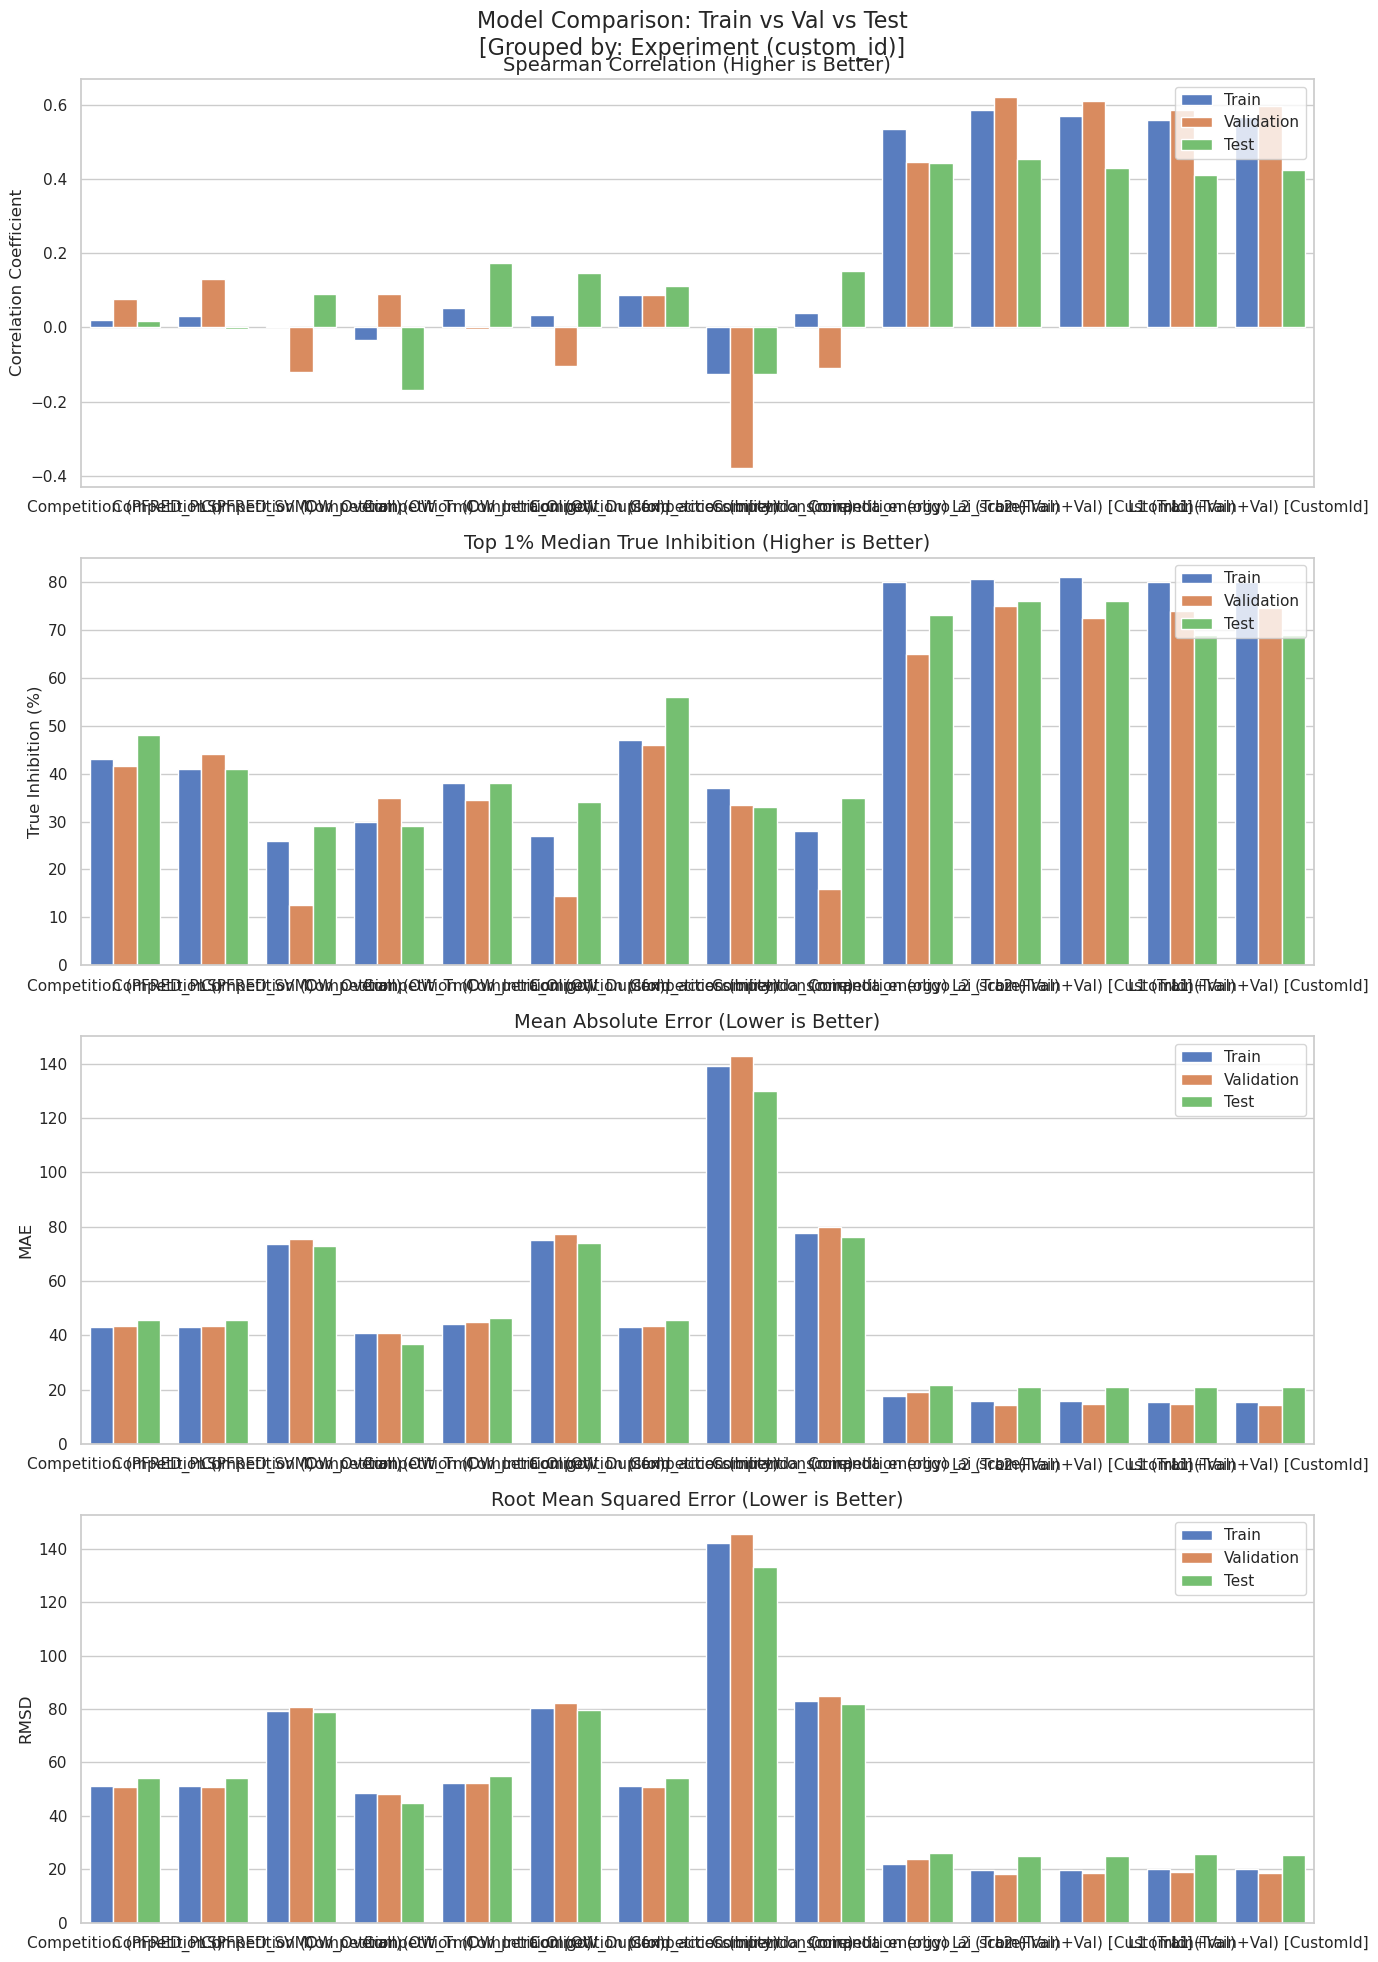

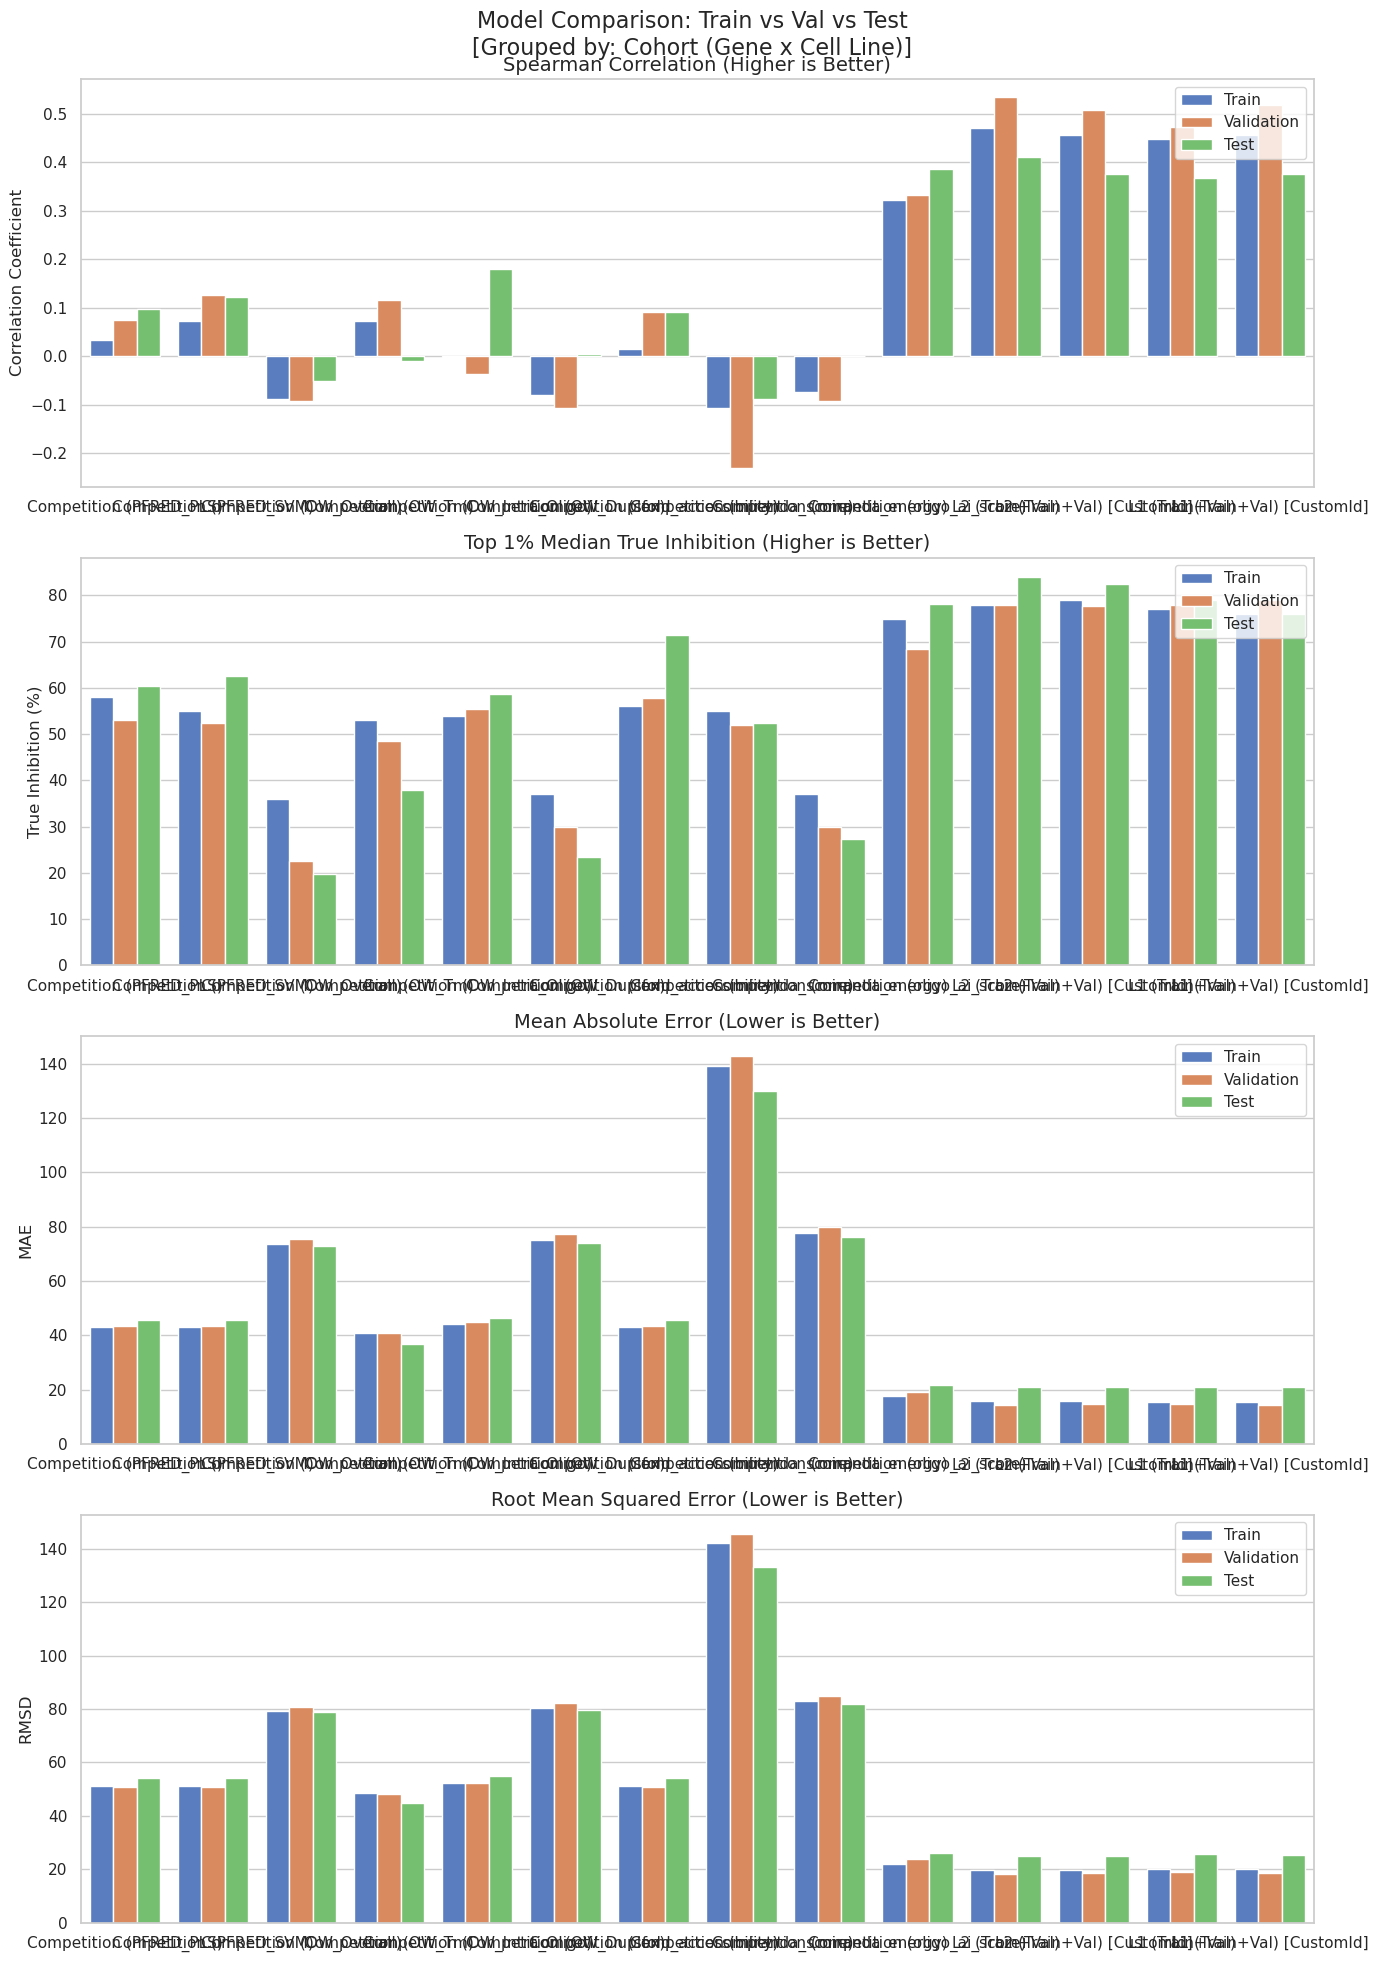

In [53]:
from tauso.data.consts import CANONICAL_GENE, CELL_LINE, INHIBITION

COMPETITION = [
    "PFRED_PLS",
    "PFRED_SVM",
    "OW_Overall",
    "OW_Tm",
    "OW_Intra_Oligo",
    "OW_Duplex",
    "sfold_accessibility",
    "miranda_score",
    "miranda_energy",
    "oligo_ai_score",
]

# 1. Dynamically create dictionary entries for all competition/baseline features
MODELS_TO_COMPARE = {
    f"Competition ({col})": {
        "is_baseline": True,
        "baseline_col": col,
        "is_all_data": False
    } for col in COMPETITION
}

# 2. Add your trained XGBoost models to the dictionary
MODELS_TO_COMPARE.update({
    "L2 (Train+Val)": {
        "path": str(SEEN_MODELS_FOLDER / "Model_Oligo_L2_TrainVal.json"),
        "is_all_data": False
    },
    "L2 (Train+Val) [CustomId]": {
    "path": str(SEEN_MODELS_FOLDER / "Model_Oligo_L2_CustomId_TrainVal.json"),
    "is_all_data": False
    },
    "L1 (Train+Val)": {
    "path": str(SEEN_MODELS_FOLDER / "Model_Oligo_L1_TrainVal.json"),
    "is_all_data": False
    },
    "L1 (Train+Val) [CustomId]": {
    "path": str(SEEN_MODELS_FOLDER / "Model_Oligo_L1_CustomId_TrainVal.json"),
    "is_all_data": False
    },
    # "L1 (Train+Val)": {
    #     "path": str(SEEN_MODELS_FOLDER / "Model_Oligo_L1_TrainVal.json"),
    #     "is_all_data": False
    # },
    # "L2 (All Data)": {
    #     "path": str(SEEN_MODELS_FOLDER / "Model_Oligo_L2_AllData.json"),
    #     "is_all_data": True
    # },
})


# Define the multiple groupings you want to track
EVAL_GROUPS = {
    'Experiment (custom_id)': 'custom_id',
    'Cohort (Gene x Cell Line)': [CANONICAL_GENE, CELL_LINE]
}

# Run Unified Evaluation
df_comparison = evaluate_multiple_models(
    model_configs=MODELS_TO_COMPARE,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    target_col=INHIBITION,
    eval_groups_dict=EVAL_GROUPS
)

print("\n--- Summary Table ---")
display(df_comparison.pivot(
    index=['Model', 'Split'],
    columns='Grouping',
    values=['Spearman', 'Top1_Inhib', 'Top5_Inhib','MAE', 'RMSD']
).round(4))

def plot_unified_comparison(df, exclude_leaked_test=True):
    """Plots metrics, generating a separate figure for each grouping strategy."""

    if exclude_leaked_test:
        df = df[df['Split'] != "Test (Leaked)"]
        split_order = ["Train", "Validation", "Test"]
    else:
        split_order = ["Train", "Validation", "Test", "Test (Leaked)"]

    for group_label in df['Grouping'].unique():

        df_group = df[df['Grouping'] == group_label]
        df_melted = df_group.melt(id_vars=['Model', 'Split', 'Grouping'], var_name='Metric', value_name='Value')

        sns.set_theme(style="whitegrid", palette="muted")
        # CHANGED: 4 subplots instead of 3, made the figure slightly taller
        fig, axes = plt.subplots(4, 1, figsize=(14, 20))
        fig.suptitle(f"Model Comparison: Train vs Val vs Test\n[Grouped by: {group_label}]", fontsize=16, y=0.98)

        # Plot A: Spearman
        spearman_data = df_melted[df_melted['Metric'] == 'Spearman']
        sns.barplot(data=spearman_data, x='Model', y='Value', hue='Split', hue_order=split_order, ax=axes[0])
        axes[0].set_title('Spearman Correlation (Higher is Better)', fontsize=14)
        axes[0].set_ylabel('Correlation Coefficient')
        axes[0].set_xlabel('')
        axes[0].legend(loc='upper right')

        # Plot B: Top 1% Inhibition
        top1_data = df_melted[df_melted['Metric'] == 'Top1_Inhib']
        sns.barplot(data=top1_data, x='Model', y='Value', hue='Split', hue_order=split_order, ax=axes[1])
        axes[1].set_title('Top 1% Median True Inhibition (Higher is Better)', fontsize=14)
        axes[1].set_ylabel('True Inhibition (%)')
        axes[1].set_xlabel('')
        axes[1].legend(loc='upper right')

        # Plot C: Error (MAE)
        mae_data = df_melted[df_melted['Metric'] == 'MAE']
        sns.barplot(data=mae_data, x='Model', y='Value', hue='Split', hue_order=split_order, ax=axes[2])
        axes[2].set_title('Mean Absolute Error (Lower is Better)', fontsize=14)
        axes[2].set_ylabel('MAE')
        axes[2].set_xlabel('')
        axes[2].legend(loc='upper right')

        # Plot D: Error (RMSD) <-- ADDED THIS BLOCK
        rmsd_data = df_melted[df_melted['Metric'] == 'RMSD']
        sns.barplot(data=rmsd_data, x='Model', y='Value', hue='Split', hue_order=split_order, ax=axes[3])
        axes[3].set_title('Root Mean Squared Error (Lower is Better)', fontsize=14)
        axes[3].set_ylabel('RMSD')
        axes[3].set_xlabel('')
        axes[3].legend(loc='upper right')

        plt.tight_layout()
        plt.show()

# Run the plot
plot_unified_comparison(df_comparison, exclude_leaked_test=True)

In [ ]:
final_data[final_data['sfold_accessibility'].notna()]